# ****BÖLÜM 0 — IMPORT & SABİT PARAMETRELER****

In [6]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 0 — IMPORT & SABİT PARAMETRELER            ║
# ║  Bu hücre tüm deneylerin ortak tabanıdır.                ║
# ║  Burası değişmeden kalır — her deney buraya dayanır.     ║
# ╚══════════════════════════════════════════════════════════════╝

import os
import re
import cv2
import time
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# ── Determinizm için seed ayarları ──
SEED = 42  # bunu not et, her yerde aynı olmalı

os.environ['PYTHONHASHSEED']       = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seed: {SEED} — tüm rastgelelikler sabitlendi.")

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from tensorflow.keras.layers import (
    TimeDistributed, Conv2D, Flatten, LSTM, GRU,
    Bidirectional, Dense, Dropout, GlobalAveragePooling2D
)
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Tekrarlanabilirlik İçin Seed ──────────────────────────────
SEED = 42

os.environ['PYTHONHASHSEED']        = str(SEED)
os.environ['TF_DETERMINISTIC_OPS']  = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seed {SEED} — sabitlendi.")

# ── Sınıflar ─────────────────────────────────────────────────
CLASSES = ["Fighting", "Vandalism", "NormalVideos"]
NUM_CLASSES = len(CLASSES)

# ── Görüntü & Sequence Parametreleri ─────────────────────────
# SEQ_LEN = 30: Her videodan eşit aralıklarla seçilen kare sayısı.
# 30 kare, hareketin akışını yakalamak için yeterli; daha fazlası
# RAM'i gereksiz yere doldurur, daha azı temporal ilişkiyi kaçırır.
# IMG_HEIGHT / IMG_WIDTH = 64: VGG16 ve MobileNetV2 her ikisi de
# bu boyutu kaldırır. 128 daha iyi olurdu ama Kaggle RAM'ine sığmaz.
IMG_HEIGHT  = 64
IMG_WIDTH   = 64
SEQ_LEN     = 30

# ── Eğitim Parametreleri ──────────────────────────────────────
# Tüm deneylerde aynı değerler kullanılır.
# Farklı bir değer denenirse burası DEĞİL, ilgili deney hücresi değişir.
BATCH_SIZE  = 4
EPOCHS      = 30
PATIENCE    = 10       # EarlyStopping: bu kadar epoch iyileşme olmazsa dur
TEST_SIZE   = 0.25     # %25 test, %75 train
FPS_TEST_N  = 10       # FPS ölçümünde kaç video kullanılacak

# ── Dataset Yolları ───────────────────────────────────────────
# Deney 1 ve 2 farklı dataset kullanacak, her ikisi de burada tanımlı.
DATASET_UCF = "/kaggle/input/datasets/odins0n/ucf-crime-dataset/Train"

# Deney 2 için ek datasetler buraya eklenecek (henüz boş)
# ── Genişletilmiş Veri Seti Yolları ──────────────────────────
DATASET_REAL_LIFE  = "/kaggle/input/datasets/mohamedmustafa/real-life-violence-situations-dataset/Real Life Violence Dataset"
DATASET_DCSASS     = "/kaggle/input/datasets/mateohervas/dcsass-dataset/DCSASS Dataset"


# Sınıf eşleştirme haritası
# Her veri setindeki klasörler → bizim 3 sınıfımızdan birine eşleniyor
DATASET_UCF101 = "/kaggle/input/datasets/abdallahwagih/ucf101-videos/train"

# Normal aktiviteler için UCF101'den kullanacağımız isimler
UCF101_NORMAL = ["ShavingBeard", "PlayingCello", "TennisSwing", "CricketShot"]

GENISLETILMIS_MAPPING = {
    "Fighting": [
        (DATASET_DCSASS,    "Fighting"),
        (DATASET_DCSASS,    "Assault"),
        (DATASET_REAL_LIFE, "Violence"),
    ],
    "Vandalism": [
        (DATASET_DCSASS, "Robbery"),
        (DATASET_DCSASS, "Arson"),
        (DATASET_DCSASS, "Burglary"),
        (DATASET_DCSASS, "Explosion"),
    ],
    "NormalVideos": [
        (DATASET_REAL_LIFE, "NonViolence"),
    ],
}

# ── Çıktı Klasörü ─────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 50)
print(f"  Sınıflar     : {CLASSES}")
print(f"  Görüntü boyutu: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"  Sequence uzunluğu: {SEQ_LEN} kare")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Max epoch    : {EPOCHS}")
print(f"  EarlyStopping: patience={PATIENCE}")
print(f"  Test oranı   : {TEST_SIZE}")
print("=" * 50)

AttributeError: 'google.protobuf.pyext._message.FieldDescriptor' object has no attribute 'is_repeated'

# ****BÖLÜM 1 — VERİ YÜKLEME & ÖN İŞLEME****

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 1 — VERİ YÜKLEME & ÖN İŞLEME                ║
# ║  Deney 1.1 ve 1.2 için ortak pipeline.                     ║
# ║  Augmentation sadece train setine uygulanır.               ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 1.1 Veri Setini Keşfet ────────────────────────────────────
# Kaç video var, kaç frame var — önce bakalım, sonra yükleyelim.

print("=" * 50)
print("VERİ SETİ ANALİZİ")
print("=" * 50)

for cls in CLASSES:
    path = os.path.join(DATASET_UCF, cls)
    files = sorted(os.listdir(path))

    videos = set()
    for f in files:
        match = re.match(r'(.+)_(\d+)\.png$', f)
        if match:
            videos.add(match.group(1))

    print(f"{cls}:")
    print(f"  Toplam video : {len(videos)}")
    print(f"  Toplam frame : {len(files)}")
print("=" * 50)

VERİ SETİ ANALİZİ
Fighting:
  Toplam video : 45
  Toplam frame : 24684
Vandalism:
  Toplam video : 45
  Toplam frame : 13626
NormalVideos:
  Toplam video : 800
  Toplam frame : 947768


In [9]:
# ── 1.2 Video Gruplarını Oluştur ──────────────────────────────
# Aynı videoya ait frame'leri bir arada tutuyoruz.
# Neden? Train/test split video bazında yapılacak.
# Frame bazında split yapılsaydı aynı videonun kareleri
# hem train'e hem test'e düşerdi → data leakage.

def get_video_groups(class_path, max_videos=30):
    files = sorted(os.listdir(class_path))
    groups = {}
    for f in files:
        match = re.match(r'(.+)_(\d+)\.png$', f)
        if match:
            video_name = match.group(1)
            frame_no   = int(match.group(2))
            if video_name not in groups:
                groups[video_name] = []
            groups[video_name].append((frame_no, f))
    for v in groups:
        groups[v].sort(key=lambda x: x[0])
    return dict(list(groups.items())[:max_videos])

In [ ]:
# ── 1.3 Sequence Oluştur ──────────────────────────────────────
# Her videodan tam olarak SEQ_LEN=30 kare seçiyoruz.
# Neden 30? Az seçersen hareket akışını kaçırırsın,
# çok seçersen RAM dolar ve eğitim yavaşlar.
# Strateji: videoyu eşit aralıklara böl, her aralıktan 1 kare al.
# Bu sayede kısa ve uzun videolar aynı boyuta normalize edilir.

def load_sequences(dataset_path, classes, max_videos=30):
    features = []
    labels   = []
    paths    = []

    for class_idx, class_name in enumerate(classes):
        print(f"Yükleniyor: {class_name}")
        class_path   = os.path.join(dataset_path, class_name)
        video_groups = get_video_groups(class_path, max_videos=max_videos)

        for video_name, frame_list in video_groups.items():
            total = len(frame_list)
            if total < SEQ_LEN:
                continue

            # Eşit aralıklı kare seçimi
            step     = max(total // SEQ_LEN, 1)
            selected = frame_list[::step][:SEQ_LEN]
            if len(selected) < SEQ_LEN:
                continue

            sequence = []
            for _, fname in selected:
                img_path = os.path.join(class_path, fname)
                img = cv2.imread(img_path)
                if img is None:
                    break
                img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
                img = img / 255.0   # Normalize: 0-255 → 0-1
                sequence.append(img)

            if len(sequence) == SEQ_LEN:
                features.append(sequence)
                labels.append(class_idx)
                paths.append(video_name)

        print(f"  {len([l for l in labels if l == class_idx])} video yüklendi")

    return np.array(features), np.array(labels), paths


features, labels, paths = load_sequences(DATASET_UCF, CLASSES, max_videos=45)

print(f"\nToplam shape : {features.shape}")
print(f"  → {features.shape[0]} video")
print(f"  → {features.shape[1]} kare/video")
print(f"  → {features.shape[2]}x{features.shape[3]} piksel")
print(f"  → {features.shape[4]} kanal (RGB)")

Yükleniyor: Fighting
  45 video yüklendi
Yükleniyor: Vandalism
  45 video yüklendi
Yükleniyor: NormalVideos


In [6]:
# ── 1.4 Train / Test Ayrımı ───────────────────────────────────
# Split ÖNCE yapılıyor, augmentation SONRA.
# Neden? Test verisi gerçek dünyayı temsil etmeli.
# Augmente edilmiş test verisiyle ölçülen accuracy şişirilmiş olur.

one_hot_labels = to_categorical(labels, num_classes=NUM_CLASSES)

features_train, features_test, labels_train, labels_test = train_test_split(
    features, one_hot_labels,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=SEED
)

print(f"Train seti : {features_train.shape[0]} video")
print(f"Test seti  : {features_test.shape[0]} video")

Train seti : 100 video
Test seti  : 34 video


In [7]:
# ── 1.5 Augmentation — Sadece Train'e ────────────────────────
# Augmentation: modele aynı videoyu farklı açılardan gösteriyoruz.
# Bu sayede model "sadece bu açıdan kavga böyle görünür" değil,
# "kavga genel olarak böyle görünür" öğreniyor.
# Test setine augmentation UYGULANMAZ.

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=(0.8, 1.2),
    shear_range=10,
    channel_shift_range=20,
    fill_mode='reflect'
)

augmented_sequences = []
for seq_idx, sequence in enumerate(features_train):
    aug_seq = []
    for frame_idx, frame in enumerate(sequence):
        frame_uint8 = (frame * 255).astype(np.uint8)
        np.random.seed(SEED + seq_idx * 100 + frame_idx)  # tekrarlanabilir
        aug_frame = datagen.random_transform(frame_uint8)
        aug_seq.append(aug_frame / 255.0)
    augmented_sequences.append(aug_seq)

# Orijinal + augmented → train seti 2 katına çıkıyor
features_train = np.concatenate([features_train, np.array(augmented_sequences)], axis=0)
labels_train   = np.concatenate([labels_train, labels_train], axis=0)

print(f"Train (augmentation sonrası) : {features_train.shape[0]} video")
print(f"Test (değişmedi)             : {features_test.shape[0]} video")

Train (augmentation sonrası) : 200 video
Test (değişmedi)             : 34 video


# ****BÖLÜM 2 — DENEY 1.1: VGG16 + LSTM****

In [8]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 2 — DENEY 1.1: VGG16 + LSTM                ║
# ║  Baz model. Yüksek doğruluk, ağır mimari.                ║
# ║  Tek model — ensemble yok.                               ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 2.1 Model Mimarisi ────────────────────────────────────────
# VGG16: Her kareyi ayrı ayrı işler, özellik çıkarır.
# Neden frozen? ImageNet'te milyonlarca görüntüyle öğrenilmiş
# ağırlıkları bozmak istemiyoruz. Sadece üstüne LSTM ekliyoruz.
# LSTM: 30 kare boyunca "ne değişti?" sorusunu yanıtlar.
# Yani VGG16 = göz, LSTM = hafıza.

def build_vgg16_lstm():
    vgg = VGG16(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    vgg.trainable = False  # Frozen — ağırlıklar güncellenmez

    model = Sequential([
        TimeDistributed(vgg, input_shape=(SEQ_LEN, IMG_HEIGHT, IMG_WIDTH, 3)),
        TimeDistributed(GlobalAveragePooling2D()),  # Flatten yerine — daha az parametre
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model


model_d11 = build_vgg16_lstm()
model_d11.summary()

I0000 00:00:1778513731.582476      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed                │ (None, 30, 2, 2, 512)  │    14,714,688 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 30, 512)        │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,862,595 (56.70 MB)

 Trainable params: 147,907 (577.76 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [9]:
# ── 2.2 Eğitim ────────────────────────────────────────────────
# EarlyStopping: val_loss izleniyor — validation kaybı
# PATIENCE epoch boyunca iyileşmezse eğitim durur.
# Neden val_loss? Train accuracy'yi izlemek overfitting'i kaçırır.
# ModelCheckpoint: En iyi validation anındaki ağırlıkları kaydeder.

callbacks_d11 = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/deney1_1_vgg16_lstm_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Deney 1.1 eğitimi başlıyor — VGG16 + LSTM")
print("=" * 50)

start_train = time.time()

history_d11 = model_d11.fit(
    x=features_train,
    y=labels_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=TEST_SIZE,
    callbacks=callbacks_d11,
    shuffle=True,
    verbose=1
)

train_time_d11 = time.time() - start_train
print(f"\nEğitim süresi: {train_time_d11/60:.1f} dakika")

Deney 1.1 eğitimi başlıyor — VGG16 + LSTM
Epoch 1/30


2026-05-11 15:35:37.803539: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1778513751.969132     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.4194 - loss: 1.1265

2026-05-11 15:35:57.959894: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from inf to 0.97804, saving model to /kaggle/working/deney1_1_vgg16_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 259ms/step - accuracy: 0.4194 - loss: 1.1261 - val_accuracy: 0.5600 - val_loss: 0.9780
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.6294 - loss: 0.9168
Epoch 2: val_loss improved from 0.97804 to 0.83798, saving model to /kaggle/working/deney1_1_vgg16_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.6281 - loss: 0.9171 - val_accuracy: 0.6600 - val_loss: 0.8380
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7497 - loss: 0.6870
Epoch 3: val_loss improved from 0.83798 to 0.77698, saving model to /kaggle/working/deney1_1_vgg16_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step - accuracy: 0.7489 - loss: 0.6875 - val_accuracy: 0.6600 - val_loss: 0.7770
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7835 - loss: 0.5229
Epoch 4: val_loss did not improve from 0.77698
38/3

In [10]:
# ── 2.3 Tahmin ────────────────────────────────────────────────

y_pred_d11     = model_d11.predict(features_test, verbose=1)
y_pred_cls_d11 = np.argmax(y_pred_d11, axis=1)
y_true         = np.argmax(labels_test, axis=1)

2026-05-11 15:38:11.565270: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 4s/step


In [11]:
# ── 2.4 Metrikler ─────────────────────────────────────────────

acc_d11  = accuracy_score(y_true, y_pred_cls_d11)
f1_d11   = f1_score(y_true, y_pred_cls_d11, average='weighted')
prec_d11 = precision_score(y_true, y_pred_cls_d11, average='weighted')
rec_d11  = recall_score(y_true, y_pred_cls_d11, average='weighted')

# Model boyutu
model_d11.save(f"{OUTPUT_DIR}/deney1_1_vgg16_lstm_final.keras")
size_d11 = os.path.getsize(f"{OUTPUT_DIR}/deney1_1_vgg16_lstm_final.keras") / (1024 * 1024)

# FPS — tek model, FPS_TEST_N video üzerinde
# 1 video = 1 tahmin. Süreyi video sayısına bölüyoruz.
start_fps = time.time()
for s in features_test[:FPS_TEST_N]:
    model_d11.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d11 = FPS_TEST_N / (time.time() - start_fps)

print("=" * 50)
print("  DENEY 1.1 — VGG16 + LSTM / UCF-CRIME")
print("=" * 50)
print(f"  Accuracy  : {acc_d11:.4f}  ({acc_d11*100:.2f}%)")
print(f"  F1 Score  : {f1_d11:.4f}")
print(f"  Precision : {prec_d11:.4f}")
print(f"  Recall    : {rec_d11:.4f}")
print(f"  FPS       : {fps_d11:.2f}")
print(f"  Boyut     : {size_d11:.1f} MB")
print("=" * 50)

2026-05-11 15:38:19.877208: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  DENEY 1.1 — VGG16 + LSTM / UCF-CRIME
  Accuracy  : 0.3824  (38.24%)
  F1 Score  : 0.3642
  Precision : 0.3705
  Recall    : 0.3824
  FPS       : 6.74
  Boyut     : 57.9 MB


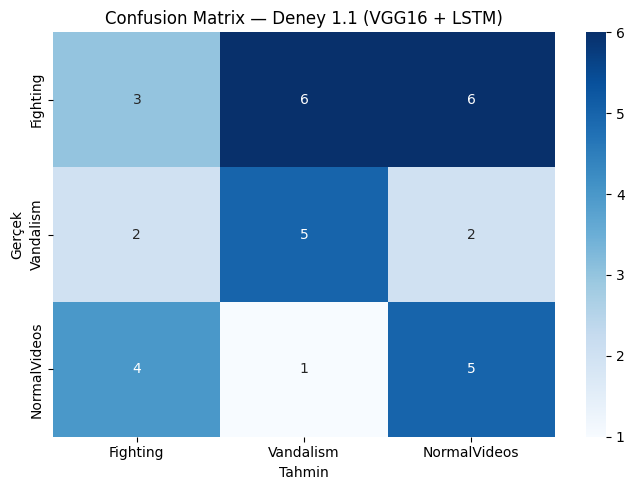

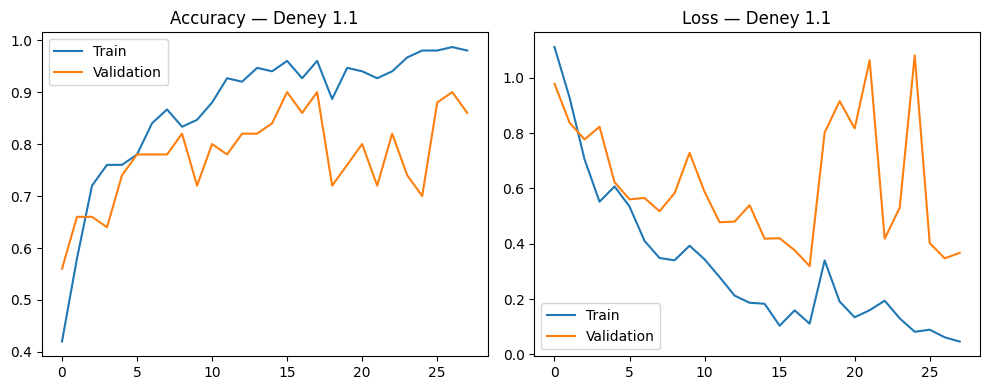

Görseller kaydedildi: /kaggle/working


In [12]:
# ── 2.5 Görseller ─────────────────────────────────────────────

# Confusion Matrix
cm_d11 = confusion_matrix(y_true, y_pred_cls_d11)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_d11, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Deney 1.1 (VGG16 + LSTM)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_deney1_1.png', dpi=150)
plt.show()

# Eğitim Eğrisi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_d11.history['accuracy'], label='Train')
plt.plot(history_d11.history['val_accuracy'], label='Validation')
plt.title('Accuracy — Deney 1.1')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_d11.history['loss'], label='Train')
plt.plot(history_d11.history['val_loss'], label='Validation')
plt.title('Loss — Deney 1.1')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/egitim_egrisi_deney1_1.png', dpi=150)
plt.show()

print(f"Görseller kaydedildi: {OUTPUT_DIR}")

In [13]:
import json

# Deney 1.1 sonuçlarını diske kaydet
results_d11 = {
    'acc': float(acc_d11),
    'f1': float(f1_d11),
    'fps': float(fps_d11),
    'size': float(size_d11)
}
with open(f"{OUTPUT_DIR}/results_d11.json", "w") as f:
    json.dump(results_d11, f)
print("Deney 1.1 sonuçları kaydedildi.")

Deney 1.1 sonuçları kaydedildi.


# ****BÖLÜM 3 — Deney 1.2: MobileNetV2 + LSTM****

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 3 — DENEY 1.2: MobileNetV2 + LSTM           ║
# ║  Hız odaklı model. VGG16 ile aynı veri, farklı backbone.  ║
# ║  Karşılaştırma: Accuracy vs FPS vs Model Boyutu            ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 3.1 Model Mimarisi ────────────────────────────────────────
# MobileNetV2: VGG16'ya göre çok daha hafif ve hızlı.
# Depthwise separable convolution kullanır — aynı işi daha az
# parametreyle yapar. Mobil ve edge cihazlar için tasarlanmış.
# VGG16 = 138M parametre, MobileNetV2 = 3.4M parametre.
# Burada da frozen kullanıyoruz — ImageNet ağırlıkları korunuyor.

def build_mobilenet_lstm():
    mobilenet = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    mobilenet.trainable = False  # Frozen

    model = Sequential([
        TimeDistributed(mobilenet, input_shape=(SEQ_LEN, IMG_HEIGHT, IMG_WIDTH, 3)),
        TimeDistributed(GlobalAveragePooling2D()),
        LSTM(64, return_sequences=False),
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model


model_d12 = build_mobilenet_lstm()
model_d12.summary()

/tmp/ipykernel_57/2700415445.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_2              │ (None, 30, 2, 2, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 30, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │       344,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,499 (9.93 MB)

 Trainable params: 344,515 (1.31 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [15]:
# ── 3.2 Eğitim ────────────────────────────────────────────────
# Deney 1.1 ile birebir aynı eğitim koşulları.
# Tek fark: model mimarisi. Bu kontrollü deney mantığı.

callbacks_d12 = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/deney1_2_mobilenet_lstm_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Deney 1.2 eğitimi başlıyor — MobileNetV2 + LSTM")
print("=" * 50)

start_train_d12 = time.time()

history_d12 = model_d12.fit(
    x=features_train,
    y=labels_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=TEST_SIZE,
    callbacks=callbacks_d12,
    shuffle=True,
    verbose=1
)

train_time_d12 = time.time() - start_train_d12
print(f"\nEğitim süresi: {train_time_d12/60:.1f} dakika")

Deney 1.2 eğitimi başlıyor — MobileNetV2 + LSTM
Epoch 1/30


2026-05-11 15:38:25.609404: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.4450 - loss: 1.1277

2026-05-11 15:40:17.784982: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from inf to 0.93712, saving model to /kaggle/working/deney1_2_mobilenet_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.4453 - loss: 1.1261 - val_accuracy: 0.5400 - val_loss: 0.9371
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9039 - loss: 0.4850
Epoch 2: val_loss improved from 0.93712 to 0.68321, saving model to /kaggle/working/deney1_2_mobilenet_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 184ms/step - accuracy: 0.9033 - loss: 0.4850 - val_accuracy: 0.7400 - val_loss: 0.6832
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9817 - loss: 0.2107
Epoch 3: val_loss improved from 0.68321 to 0.51851, saving model to /kaggle/working/deney1_2_mobilenet_lstm_best.keras
38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.9813 - loss: 0.2105 - val_accuracy: 0.7800 - val_loss: 0.5185
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9952 - loss: 0.0982
Epoch 4: val_loss improved from 0.5185

In [16]:
# ── 3.3 Tahmin ────────────────────────────────────────────────

y_pred_d12     = model_d12.predict(features_test, verbose=1)
y_pred_cls_d12 = np.argmax(y_pred_d12, axis=1)

2026-05-11 15:42:28.809352: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


2/2 ━━━━━━━━━━━━━━━━━━━━ 65s 32s/step


In [17]:
# ── 3.4 Metrikler
y_true = np.argmax(labels_test, axis=1)  # ← EN ÜSTE OLMALI

acc_d12  = accuracy_score(y_true, y_pred_cls_d12)
f1_d12   = f1_score(y_true, y_pred_cls_d12, average='weighted')
prec_d12 = precision_score(y_true, y_pred_cls_d12, average='weighted')
rec_d12  = recall_score(y_true, y_pred_cls_d12, average='weighted')

# Model boyutu
model_d12.save(f"{OUTPUT_DIR}/deney1_2_mobilenet_lstm_final.keras")
size_d12 = os.path.getsize(f"{OUTPUT_DIR}/deney1_2_mobilenet_lstm_final.keras") / (1024 * 1024)

# FPS
start_fps = time.time()
for s in features_test[:FPS_TEST_N]:
    model_d12.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d12 = FPS_TEST_N / (time.time() - start_fps)

print("=" * 50)
print("  DENEY 1.2 — MobileNetV2 + LSTM / UCF-CRIME")
print("=" * 50)
print(f"  Accuracy  : {acc_d12:.4f}  ({acc_d12*100:.2f}%)")
print(f"  F1 Score  : {f1_d12:.4f}")
print(f"  Precision : {prec_d12:.4f}")
print(f"  Recall    : {rec_d12:.4f}")
print(f"  FPS       : {fps_d12:.2f}")
print(f"  Boyut     : {size_d12:.1f} MB")
print("=" * 50)

2026-05-11 15:43:34.091003: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  DENEY 1.2 — MobileNetV2 + LSTM / UCF-CRIME
  Accuracy  : 0.4118  (41.18%)
  F1 Score  : 0.4185
  Precision : 0.5048
  Recall    : 0.4118
  FPS       : 4.99
  Boyut     : 13.1 MB


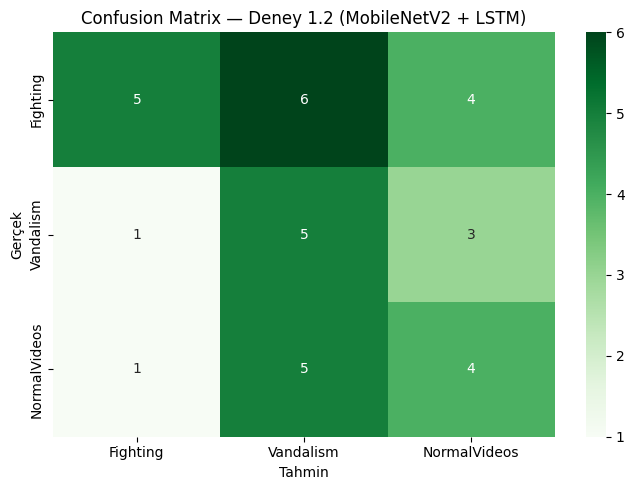

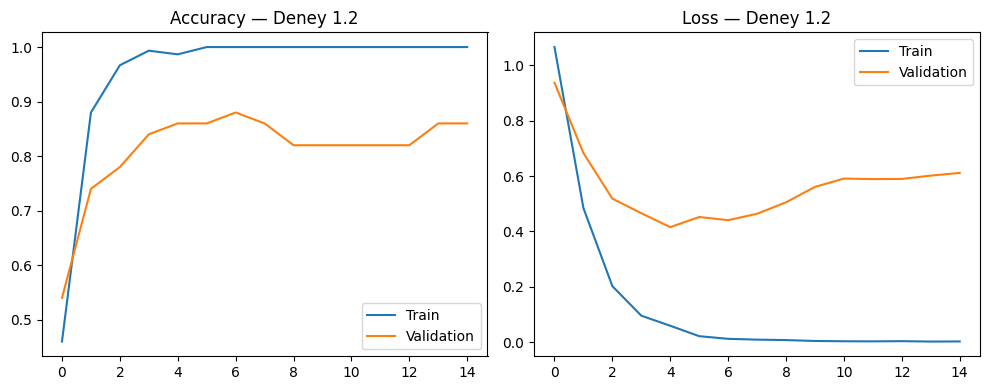

Görseller kaydedildi: /kaggle/working


In [18]:
# ── 3.5 Görseller ─────────────────────────────────────────────

# Confusion Matrix
cm_d12 = confusion_matrix(y_true, y_pred_cls_d12)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_d12, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Deney 1.2 (MobileNetV2 + LSTM)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_deney1_2.png', dpi=150)
plt.show()

# Eğitim Eğrisi
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_d12.history['accuracy'], label='Train')
plt.plot(history_d12.history['val_accuracy'], label='Validation')
plt.title('Accuracy — Deney 1.2')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_d12.history['loss'], label='Train')
plt.plot(history_d12.history['val_loss'], label='Validation')
plt.title('Loss — Deney 1.2')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/egitim_egrisi_deney1_2.png', dpi=150)
plt.show()

print(f"Görseller kaydedildi: {OUTPUT_DIR}")

In [19]:
# ── 3.6 Deney 1 Karşılaştırma Özeti ──────────────────────────

y_true = np.argmax(labels_test, axis=1)

# Deney 1.1 metrikleri
y_pred_cls_d11 = np.argmax(model_d11.predict(features_test, verbose=0), axis=1)
acc_d11  = accuracy_score(y_true, y_pred_cls_d11)
f1_d11   = f1_score(y_true, y_pred_cls_d11, average='weighted')
size_d11 = os.path.getsize(f"{OUTPUT_DIR}/deney1_1_vgg16_lstm_final.keras") / (1024 * 1024)
start_fps = time.time()
for s in features_test[:FPS_TEST_N]:
    model_d11.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d11 = FPS_TEST_N / (time.time() - start_fps)

# Deney 1.2 metrikleri
y_pred_cls_d12 = np.argmax(model_d12.predict(features_test, verbose=0), axis=1)
acc_d12  = accuracy_score(y_true, y_pred_cls_d12)
f1_d12   = f1_score(y_true, y_pred_cls_d12, average='weighted')
size_d12 = os.path.getsize(f"{OUTPUT_DIR}/deney1_2_mobilenet_lstm_final.keras") / (1024 * 1024)
start_fps = time.time()
for s in features_test[:FPS_TEST_N]:
    model_d12.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d12 = FPS_TEST_N / (time.time() - start_fps)

# Sonuçları sakla
results = {}
results['d11'] = {'acc': acc_d11, 'f1': f1_d11, 'fps': fps_d11, 'size': size_d11}
results['d12'] = {'acc': acc_d12, 'f1': f1_d12, 'fps': fps_d12, 'size': size_d12}

# Karşılaştırma tablosu
print("=" * 55)
print("  DENEY 1 — VGG16 + LSTM  vs  MobileNetV2 + LSTM")
print("=" * 55)
print(f"{'Metrik':<15} {'Deney 1.1 (VGG16)':>18} {'Deney 1.2 (Mobile)':>18}")
print("-" * 55)
print(f"{'Accuracy (%)':<15} {acc_d11*100:>18.2f} {acc_d12*100:>18.2f}")
print(f"{'F1 Score':<15} {f1_d11:>18.4f} {f1_d12:>18.4f}")
print(f"{'FPS':<15} {fps_d11:>18.2f} {fps_d12:>18.2f}")
print(f"{'Boyut (MB)':<15} {size_d11:>18.1f} {size_d12:>18.1f}")
print("=" * 55)

2026-05-11 15:43:39.216206: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  DENEY 1 — VGG16 + LSTM  vs  MobileNetV2 + LSTM
Metrik           Deney 1.1 (VGG16) Deney 1.2 (Mobile)
-------------------------------------------------------
Accuracy (%)                 38.24              41.18
F1 Score                    0.3642             0.4185
FPS                           6.60               5.22
Boyut (MB)                    57.9               13.1


# **BÖLÜM 4 — Deney 2: MobileNetV2 + LSTM + Genişletilmiş Veri Seti(UCF/KTH/DCASS/REALLIFE)***

In [20]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 4 — DENEY 2: GENİŞLETİLMİŞ VERİ SETİ       ║
# ║  UCF-Crime + Real Life + DCSASS + KTH birleştiriliyor.     ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 4.1 Video'dan Frame Çıkaran Fonksiyon ────────────────────
# UCF-Crime zaten PNG olarak geldi.
# Diğer veri setleri ham video (.mp4, .avi) olarak geliyor.
# Bu fonksiyon videoyu açıp SEQ_LEN kadar eşit aralıklı frame alıyor.

def load_sequence_from_video(video_path):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < SEQ_LEN:
        cap.release()
        return None
    
    # Eşit aralıklı frame indeksleri
    indices = np.linspace(0, total_frames - 1, SEQ_LEN, dtype=int)
    
    sequence = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            break
        frame = cv2.resize(frame, (IMG_WIDTH, IMG_HEIGHT))
        frame = frame / 255.0
        sequence.append(frame)
    
    cap.release()
    
    if len(sequence) == SEQ_LEN:
        return np.array(sequence)
    return None

print("✅ Video yükleyici hazır.")

✅ Video yükleyici hazır.


In [21]:
# ── 4.2 Genişletilmiş Veri Seti Yükleyici ────────────────────
# DCSASS'ta klasörler içinde frame'ler var (video klasörü gibi davranıyor)
# Real Life ve KTH'de direkt video dosyaları var
# Bu fonksiyon ikisini de hallediyor.

def load_sequence_from_folder(folder_path):
    """DCSASS için — klasör içindeki frame'leri sıraya dizer."""
    files = sorted([
        f for f in os.listdir(folder_path)
        if f.endswith(('.png', '.jpg', '.jpeg'))
    ])
    if len(files) < SEQ_LEN:
        return None
    
    indices = np.linspace(0, len(files) - 1, SEQ_LEN, dtype=int)
    sequence = []
    for idx in indices:
        img_path = os.path.join(folder_path, files[idx])
        img = cv2.imread(img_path)
        if img is None:
            break
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0
        sequence.append(img)
    
    if len(sequence) == SEQ_LEN:
        return np.array(sequence)
    return None


def load_genisletilmis_dataset(mapping, max_videos_per_source=20):
    """
    GENISLETILMIS_MAPPING'i gezerek tüm veri setlerini yükler.
    Her kaynak klasörden max_videos_per_source kadar video alır.
    """
    features = []
    labels   = []
    
    for class_idx, (class_name, sources) in enumerate(mapping.items()):
        print(f"\n{'='*40}")
        print(f"Sınıf: {class_name} (idx={class_idx})")
        class_count = 0
        
        for base_path, folder_name in sources:
            source_path = os.path.join(base_path, folder_name)
            
            if not os.path.exists(source_path):
                print(f"  ⚠️  Bulunamadı: {source_path}")
                continue
            
            items = sorted(os.listdir(source_path))
            loaded = 0
            
            for item in items:
                if loaded >= max_videos_per_source:
                    break
                
                item_path = os.path.join(source_path, item)
                seq = None
                
                # DCSASS: klasör içinde frame'ler var
                if os.path.isdir(item_path):
                    seq = load_sequence_from_folder(item_path)
                
                # Real Life / KTH: direkt video dosyası
                elif item.endswith(('.mp4', '.avi')):
                    seq = load_sequence_from_video(item_path)
                
                if seq is not None:
                    features.append(seq)
                    labels.append(class_idx)
                    loaded += 1
            
            print(f"  ✅ {folder_name:<20} → {loaded} video yüklendi")
            class_count += loaded
        
        print(f"  Toplam {class_name}: {class_count} video")
    
    return np.array(features), np.array(labels)


print("✅ Genişletilmiş veri yükleyici hazır.")

✅ Genişletilmiş veri yükleyici hazır.


In [22]:
# ── DCSASS için özel yükleyici ────────────────────────────────
# DCSASS yapısı: Sınıf/ → Video.mp4/ → küçük_klip.mp4
# Her alt klasördeki .mp4 kliplerini video olarak yüklüyoruz.

def load_genisletilmis_dataset(mapping, max_videos_per_source=20):
    features = []
    labels   = []
    
    for class_idx, (class_name, sources) in enumerate(mapping.items()):
        print(f"\n{'='*40}")
        print(f"Sınıf: {class_name} (idx={class_idx})")
        class_count = 0
        
        for base_path, folder_name in sources:
            source_path = os.path.join(base_path, folder_name)
            
            if not os.path.exists(source_path):
                print(f"  ⚠️  Bulunamadı: {source_path}")
                continue
            
            items = sorted(os.listdir(source_path))
            loaded = 0
            
            for item in items:
                if loaded >= max_videos_per_source:
                    break
                
                item_path = os.path.join(source_path, item)
                seq = None
                
                # DCSASS: klasör içinde küçük .mp4 klipleri var
                if os.path.isdir(item_path):
                    klips = sorted([
                        f for f in os.listdir(item_path)
                        if f.endswith('.mp4')
                    ])
                    for klip in klips:
                        if loaded >= max_videos_per_source:
                            break
                        klip_path = os.path.join(item_path, klip)
                        seq = load_sequence_from_video(klip_path)
                        if seq is not None:
                            features.append(seq)
                            labels.append(class_idx)
                            loaded += 1
                    continue
                
                # Real Life / KTH: direkt video dosyası
                elif item.endswith(('.mp4', '.avi')):
                    seq = load_sequence_from_video(item_path)
                
                if seq is not None:
                    features.append(seq)
                    labels.append(class_idx)
                    loaded += 1
            
            print(f"  ✅ {folder_name:<20} → {loaded} video yüklendi")
            class_count += loaded
        
        print(f"  Toplam {class_name}: {class_count} video")
    
    return np.array(features), np.array(labels)

print("✅ DCSASS destekli yükleyici hazır.")

✅ DCSASS destekli yükleyici hazır.


In [23]:
# ── 4.3 Veriyi Yükle ─────────────────────────────────────────
print("Genişletilmiş veri seti yükleniyor...")
print("Bu işlem birkaç dakika sürebilir.")
print("=" * 40)

# UCF-Crime yükle
features_ucf, labels_ucf, _ = load_sequences(DATASET_UCF, CLASSES, max_videos=45)

# Ek datasetleri yükle (DCSASS + Real Life + KTH)
features_extra, labels_extra = load_genisletilmis_dataset(
    GENISLETILMIS_MAPPING,
    max_videos_per_source=20
)

# İkisini birleştir
features_gen = np.concatenate([features_ucf, features_extra], axis=0)
labels_gen   = np.concatenate([labels_ucf,   labels_extra],   axis=0)

print(f"UCF-Crime        : {len(features_ucf)} video")
print(f"Ek datasetler    : {len(features_extra)} video")
print(f"TOPLAM           : {len(features_gen)} video")

print(f"\n{'='*40}")
print(f"Toplam yüklenen video : {len(features_gen)}")
print(f"Shape                 : {features_gen.shape}")
print(f"Label dağılımı:")
for i, cls in enumerate(CLASSES):
    count = np.sum(labels_gen == i)
    print(f"  {cls:<15} : {count} video")
print("=" * 40)

Genişletilmiş veri seti yükleniyor...
Bu işlem birkaç dakika sürebilir.
Yükleniyor: Fighting
  45 video yüklendi
Yükleniyor: Vandalism
  45 video yüklendi
Yükleniyor: NormalVideos
  44 video yüklendi

Sınıf: Fighting (idx=0)
  ✅ Fighting             → 20 video yüklendi
  ✅ Assault              → 20 video yüklendi
  ✅ Violence             → 20 video yüklendi
  Toplam Fighting: 60 video

Sınıf: Vandalism (idx=1)
  ✅ Robbery              → 20 video yüklendi
  ✅ Arson                → 20 video yüklendi
  ✅ Burglary             → 20 video yüklendi
  ✅ Explosion            → 20 video yüklendi
  Toplam Vandalism: 80 video

Sınıf: NormalVideos (idx=2)
  ✅ NonViolence          → 20 video yüklendi
  Toplam NormalVideos: 20 video
UCF-Crime        : 134 video
Ek datasetler    : 160 video
TOPLAM           : 294 video

Toplam yüklenen video : 294
Shape                 : (294, 30, 64, 64, 3)
Label dağılımı:
  Fighting        : 105 video
  Vandalism       : 125 video
  NormalVideos    : 64 video


In [24]:
# ── 4.4 Train/Test Split ─────────────────────────────────────
one_hot_labels_gen = to_categorical(labels_gen, num_classes=NUM_CLASSES)

features_train_gen, features_test_gen, labels_train_gen, labels_test_gen = train_test_split(
    features_gen, one_hot_labels_gen,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=SEED
)

print(f"Train seti : {features_train_gen.shape[0]} video")
print(f"Test seti  : {features_test_gen.shape[0]} video")

# ── 4.5 Augmentation ─────────────────────────────────────────
augmented_sequences_gen = []
for seq_idx, sequence in enumerate(features_train_gen):
    aug_seq = []
    for frame_idx, frame in enumerate(sequence):
        frame_uint8 = (frame * 255).astype(np.uint8)
        np.random.seed(SEED + seq_idx * 100 + frame_idx)
        aug_frame = datagen.random_transform(frame_uint8)
        aug_seq.append(aug_frame / 255.0)
    augmented_sequences_gen.append(aug_seq)

features_train_gen = np.concatenate(
    [features_train_gen, np.array(augmented_sequences_gen)], axis=0
)
labels_train_gen = np.concatenate(
    [labels_train_gen, labels_train_gen], axis=0
)

print(f"Train (augmentation sonrası) : {features_train_gen.shape[0]} video")
print(f"Test (değişmedi)             : {features_test_gen.shape[0]} video")

Train seti : 220 video
Test seti  : 74 video
Train (augmentation sonrası) : 440 video
Test (değişmedi)             : 74 video


In [25]:
# ── 4.6 Model — MobileNetV2 + LSTM (Genişletilmiş Veri) ──────
model_d2 = build_mobilenet_lstm()

callbacks_d2 = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/deney2_mobilenet_lstm_genisletilmis_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Deney 2 eğitimi başlıyor — MobileNetV2 + LSTM + Genişletilmiş Veri")
print("=" * 50)

start_train_d2 = time.time()
history_d2 = model_d2.fit(
    x=features_train_gen,
    y=labels_train_gen,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=TEST_SIZE,
    callbacks=callbacks_d2,
    shuffle=True,
    verbose=1
)
train_time_d2 = time.time() - start_train_d2
print(f"\nEğitim süresi: {train_time_d2/60:.1f} dakika")

/tmp/ipykernel_57/2700415445.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Deney 2 eğitimi başlıyor — MobileNetV2 + LSTM + Genişletilmiş Veri
Epoch 1/30


2026-05-11 15:45:39.707684: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.5013 - loss: 0.9916

2026-05-11 15:47:37.508510: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from inf to 0.68747, saving model to /kaggle/working/deney2_mobilenet_lstm_genisletilmis_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 158s 624ms/step - accuracy: 0.5027 - loss: 0.9898 - val_accuracy: 0.6909 - val_loss: 0.6875
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8647 - loss: 0.3664
Epoch 2: val_loss improved from 0.68747 to 0.63793, saving model to /kaggle/working/deney2_mobilenet_lstm_genisletilmis_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 0.8648 - loss: 0.3660 - val_accuracy: 0.7091 - val_loss: 0.6379
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9537 - loss: 0.1714
Epoch 3: val_loss did not improve from 0.63793
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 172ms/step - accuracy: 0.9539 - loss: 0.1711 - val_accuracy: 0.7273 - val_loss: 0.7079
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9910 - loss: 0.0646
Epoch 4: val_loss did not improve from 0.63793
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 172

2026-05-11 15:52:06.906699: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 16s/step


2026-05-11 15:53:12.457746: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  DENEY 2 — MobileNetV2 + LSTM / GENİŞLETİLMİŞ VERİ
  Accuracy  : 0.7432  (74.32%)
  F1 Score  : 0.7455
  Precision : 0.7615
  Recall    : 0.7432
  FPS       : 5.13
  Boyut     : 13.1 MB


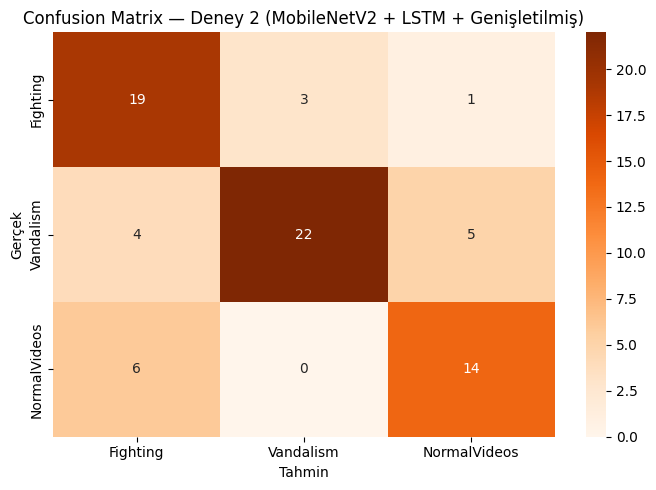

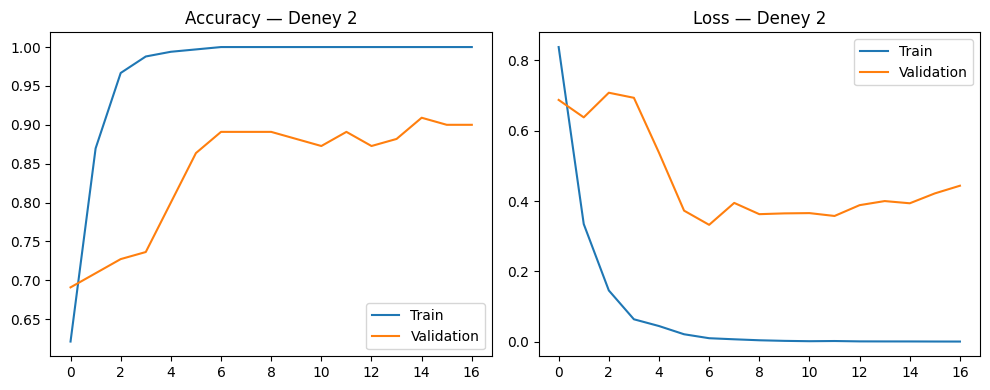

Görseller kaydedildi: /kaggle/working


In [26]:
# ── 4.7 Tahmin ────────────────────────────────────────────────
y_pred_d2     = model_d2.predict(features_test_gen, verbose=1)
y_pred_cls_d2 = np.argmax(y_pred_d2, axis=1)
y_true_gen    = np.argmax(labels_test_gen, axis=1)

# ── 4.8 Metrikler ─────────────────────────────────────────────
acc_d2  = accuracy_score(y_true_gen, y_pred_cls_d2)
f1_d2   = f1_score(y_true_gen, y_pred_cls_d2, average='weighted')
prec_d2 = precision_score(y_true_gen, y_pred_cls_d2, average='weighted')
rec_d2  = recall_score(y_true_gen, y_pred_cls_d2, average='weighted')

model_d2.save(f"{OUTPUT_DIR}/deney2_mobilenet_lstm_genisletilmis_final.keras")
size_d2 = os.path.getsize(f"{OUTPUT_DIR}/deney2_mobilenet_lstm_genisletilmis_final.keras") / (1024 * 1024)

start_fps = time.time()
for s in features_test_gen[:FPS_TEST_N]:
    model_d2.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d2 = FPS_TEST_N / (time.time() - start_fps)

print("=" * 50)
print("  DENEY 2 — MobileNetV2 + LSTM / GENİŞLETİLMİŞ VERİ")
print("=" * 50)
print(f"  Accuracy  : {acc_d2:.4f}  ({acc_d2*100:.2f}%)")
print(f"  F1 Score  : {f1_d2:.4f}")
print(f"  Precision : {prec_d2:.4f}")
print(f"  Recall    : {rec_d2:.4f}")
print(f"  FPS       : {fps_d2:.2f}")
print(f"  Boyut     : {size_d2:.1f} MB")
print("=" * 50)

# ── 4.9 Görseller ─────────────────────────────────────────────
cm_d2 = confusion_matrix(y_true_gen, y_pred_cls_d2)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_d2, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Deney 2 (MobileNetV2 + LSTM + Genişletilmiş)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_deney2.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_d2.history['accuracy'], label='Train')
plt.plot(history_d2.history['val_accuracy'], label='Validation')
plt.title('Accuracy — Deney 2')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_d2.history['loss'], label='Train')
plt.plot(history_d2.history['val_loss'], label='Validation')
plt.title('Loss — Deney 2')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/egitim_egrisi_deney2.png', dpi=150)
plt.show()

print(f"Görseller kaydedildi: {OUTPUT_DIR}")

# **BÖLÜM 5 — Deney 3.1: Kazanan CNN + GRU (Genişletilmiş Veri Seti)**

In [27]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 5 — DENEY 3.1: KAZANAN CNN + GRU            ║
# ║  Veri: UCF-Crime + KTH + DCSASS + Real Life Violence       ║
# ║  Fark: LSTM yerine GRU — daha hızlı, daha az parametre.   ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 5.1 Model Mimarisi ────────────────────────────────────────
# GRU (Gated Recurrent Unit), LSTM'in daha sade bir versiyonudur.
# LSTM'de 3 kapı vardır (forget, input, output).
# GRU'da 2 kapı vardır (reset, update) — daha az parametre.
# Sonuç: Benzer accuracy, daha hızlı eğitim, daha küçük model.
# Hipotez: Kısa aksiyon sekanslarında GRU yeterli olabilir.

def build_mobilenet_gru():
    mobilenet = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    mobilenet.trainable = False

    model = Sequential([
        TimeDistributed(mobilenet, input_shape=(SEQ_LEN, IMG_HEIGHT, IMG_WIDTH, 3)),
        TimeDistributed(GlobalAveragePooling2D()),
        GRU(64, return_sequences=False),   # LSTM yerine GRU
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_d31 = build_mobilenet_gru()
model_d31.summary()


/tmp/ipykernel_57/752224701.py:15: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_6              │ (None, 30, 2, 2, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 30, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │       258,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,516,611 (9.60 MB)

 Trainable params: 258,627 (1010.26 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [28]:
# ── 5.2 Eğitim ────────────────────────────────────────────────
# Deney 2 ile aynı veri (features_train_gen, features_test_gen).
# Tek fark: GRU kullanılıyor.
# Bu kontrollü deney mantığı: sadece bir değişken farklı.

callbacks_d31 = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/deney3_1_mobilenet_gru_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Deney 3.1 eğitimi başlıyor — MobileNetV2 + GRU + Genişletilmiş Veri")
print("=" * 50)

start_train_d31 = time.time()
history_d31 = model_d31.fit(
    x=features_train_gen,
    y=labels_train_gen,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=TEST_SIZE,
    callbacks=callbacks_d31,
    shuffle=True,
    verbose=1
)
train_time_d31 = time.time() - start_train_d31
print(f"\nEğitim süresi: {train_time_d31/60:.1f} dakika")


Deney 3.1 eğitimi başlıyor — MobileNetV2 + GRU + Genişletilmiş Veri
Epoch 1/30


2026-05-11 15:53:20.333239: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.4776 - loss: 1.0567

2026-05-11 15:55:19.993113: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from inf to 0.77748, saving model to /kaggle/working/deney3_1_mobilenet_gru_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 160s 618ms/step - accuracy: 0.4791 - loss: 1.0546 - val_accuracy: 0.6545 - val_loss: 0.7775
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9219 - loss: 0.2657
Epoch 2: val_loss improved from 0.77748 to 0.60222, saving model to /kaggle/working/deney3_1_mobilenet_gru_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 178ms/step - accuracy: 0.9219 - loss: 0.2658 - val_accuracy: 0.7455 - val_loss: 0.6022
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.9831 - loss: 0.1061
Epoch 3: val_loss improved from 0.60222 to 0.51086, saving model to /kaggle/working/deney3_1_mobilenet_gru_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.9831 - loss: 0.1060 - val_accuracy: 0.7545 - val_loss: 0.5109
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.9919 - loss: 0.0504
Epoch 4: val_loss improved from 0.51

In [29]:
# ── 5.3 Tahmin & Metrikler ────────────────────────────────────

y_pred_d31     = model_d31.predict(features_test_gen, verbose=1)
y_pred_cls_d31 = np.argmax(y_pred_d31, axis=1)
y_true_gen     = np.argmax(labels_test_gen, axis=1)

acc_d31  = accuracy_score(y_true_gen, y_pred_cls_d31)
f1_d31   = f1_score(y_true_gen, y_pred_cls_d31, average='weighted')
prec_d31 = precision_score(y_true_gen, y_pred_cls_d31, average='weighted')
rec_d31  = recall_score(y_true_gen, y_pred_cls_d31, average='weighted')

model_d31.save(f"{OUTPUT_DIR}/deney3_1_mobilenet_gru_final.keras")
size_d31 = os.path.getsize(f"{OUTPUT_DIR}/deney3_1_mobilenet_gru_final.keras") / (1024 * 1024)

start_fps = time.time()
for s in features_test_gen[:FPS_TEST_N]:
    model_d31.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d31 = FPS_TEST_N / (time.time() - start_fps)

print("=" * 50)
print("  DENEY 3.1 — MobileNetV2 + GRU / GENİŞLETİLMİŞ VERİ")
print("=" * 50)
print(f"  Accuracy  : {acc_d31:.4f}  ({acc_d31*100:.2f}%)")
print(f"  F1 Score  : {f1_d31:.4f}")
print(f"  Precision : {prec_d31:.4f}")
print(f"  Recall    : {rec_d31:.4f}")
print(f"  FPS       : {fps_d31:.2f}")
print(f"  Boyut     : {size_d31:.1f} MB")
print("=" * 50)


2026-05-11 15:59:31.650351: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


3/3 ━━━━━━━━━━━━━━━━━━━━ 65s 16s/step


2026-05-11 16:00:37.161086: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  DENEY 3.1 — MobileNetV2 + GRU / GENİŞLETİLMİŞ VERİ
  Accuracy  : 0.7027  (70.27%)
  F1 Score  : 0.7066
  Precision : 0.7258
  Recall    : 0.7027
  FPS       : 5.04
  Boyut     : 12.1 MB


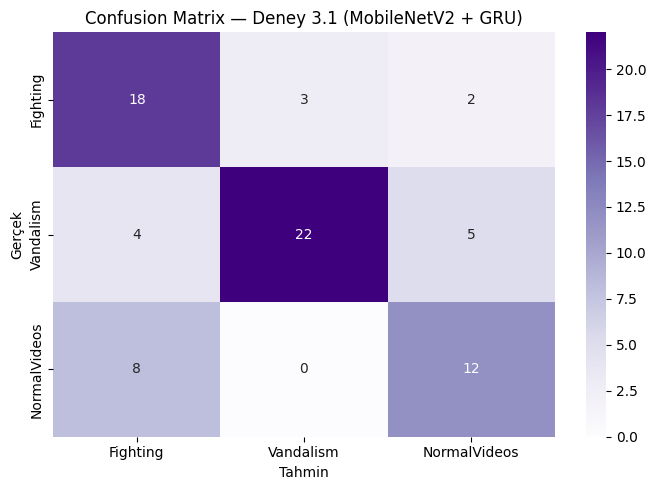

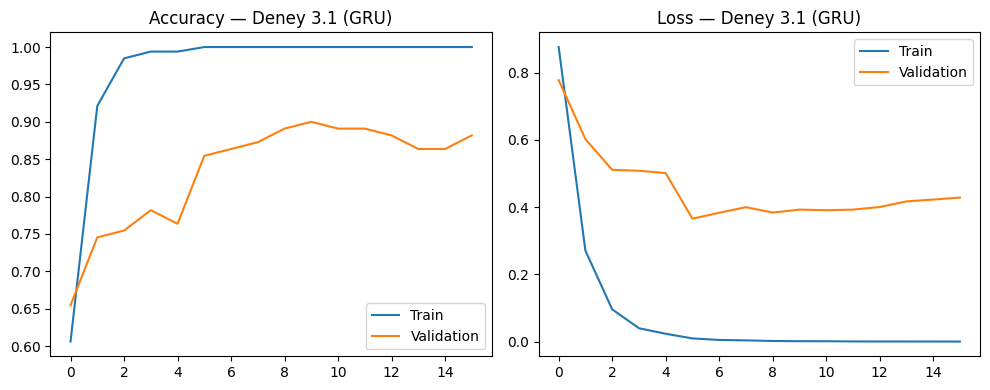

Görseller kaydedildi: /kaggle/working


In [30]:
# ── 5.4 Görseller ─────────────────────────────────────────────

cm_d31 = confusion_matrix(y_true_gen, y_pred_cls_d31)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_d31, annot=True, fmt='d', cmap='Purples',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Deney 3.1 (MobileNetV2 + GRU)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_deney3_1.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_d31.history['accuracy'], label='Train')
plt.plot(history_d31.history['val_accuracy'], label='Validation')
plt.title('Accuracy — Deney 3.1 (GRU)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_d31.history['loss'], label='Train')
plt.plot(history_d31.history['val_loss'], label='Validation')
plt.title('Loss — Deney 3.1 (GRU)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/egitim_egrisi_deney3_1.png', dpi=150)
plt.show()

print(f"Görseller kaydedildi: {OUTPUT_DIR}")


# **BÖLÜM 6 — Deney 3.2: Kazanan CNN + BiLSTM (Genişletilmiş Veri Seti)**

In [31]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 6 — DENEY 3.2: KAZANAN CNN + BiLSTM         ║
# ║  Veri: UCF-Crime + KTH + DCSASS + Real Life Violence       ║
# ║  Fark: Bidirectional LSTM — hem ileri hem geri okur.       ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 6.1 Model Mimarisi ────────────────────────────────────────
# Bidirectional LSTM: Aynı sekansı iki yönde işler.
# İleri pass (t=0→30): "kavga nasıl başladı?"
# Geri pass (t=30→0): "kavga nasıl bitti?"
# İki yönlü bağlam → daha zengin temporal temsil.
# Dezavantaj: 2× parametre, 2× bellek, daha yavaş.
# Hipotez: BiLSTM, hareketin başını ve sonunu birlikte
# görebildiği için LSTM'den daha doğru sınıflandırabilir.

def build_mobilenet_bilstm():
    mobilenet = MobileNetV2(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
    )
    mobilenet.trainable = False

    model = Sequential([
        TimeDistributed(mobilenet, input_shape=(SEQ_LEN, IMG_HEIGHT, IMG_WIDTH, 3)),
        TimeDistributed(GlobalAveragePooling2D()),
        Bidirectional(LSTM(64, return_sequences=False)),  # BiLSTM
        Dropout(0.3),
        Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        loss='categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

model_d32 = build_mobilenet_bilstm()
model_d32.summary()


/tmp/ipykernel_57/3073552014.py:17: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNetV2(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ time_distributed_8              │ (None, 30, 2, 2, 1280) │     2,257,984 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 30, 1280)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │       688,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,947,011 (11.24 MB)

 Trainable params: 689,027 (2.63 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
# ── 6.2 Eğitim ────────────────────────────────────────────────
# Deney 2 ve 3.1 ile aynı veri ve hyperparameter'lar.
# Tek fark: Bidirectional(LSTM) kullanılıyor.

callbacks_d32 = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/deney3_2_mobilenet_bilstm_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Deney 3.2 eğitimi başlıyor — MobileNetV2 + BiLSTM + Genişletilmiş Veri")
print("=" * 50)

start_train_d32 = time.time()
history_d32 = model_d32.fit(
    x=features_train_gen,
    y=labels_train_gen,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=TEST_SIZE,
    callbacks=callbacks_d32,
    shuffle=True,
    verbose=1
)
train_time_d32 = time.time() - start_train_d32
print(f"\nEğitim süresi: {train_time_d32/60:.1f} dakika")


Deney 3.2 eğitimi başlıyor — MobileNetV2 + BiLSTM + Genişletilmiş Veri
Epoch 1/30


2026-05-11 16:00:42.512374: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.5129 - loss: 0.9175

2026-05-11 16:02:42.888486: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from inf to 0.66407, saving model to /kaggle/working/deney3_2_mobilenet_bilstm_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 162s 637ms/step - accuracy: 0.5143 - loss: 0.9157 - val_accuracy: 0.6818 - val_loss: 0.6641
Epoch 2/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9509 - loss: 0.2151
Epoch 2: val_loss improved from 0.66407 to 0.42405, saving model to /kaggle/working/deney3_2_mobilenet_bilstm_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 179ms/step - accuracy: 0.9507 - loss: 0.2152 - val_accuracy: 0.8273 - val_loss: 0.4241
Epoch 3/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9957 - loss: 0.0732
Epoch 3: val_loss improved from 0.42405 to 0.37568, saving model to /kaggle/working/deney3_2_mobilenet_bilstm_best.keras
83/83 ━━━━━━━━━━━━━━━━━━━━ 15s 180ms/step - accuracy: 0.9956 - loss: 0.0732 - val_accuracy: 0.8364 - val_loss: 0.3757
Epoch 4/30
83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9977 - loss: 0.0316
Epoch 4: val_loss improved 

In [33]:
# ── 6.3 Tahmin & Metrikler ────────────────────────────────────

y_pred_d32     = model_d32.predict(features_test_gen, verbose=1)
y_pred_cls_d32 = np.argmax(y_pred_d32, axis=1)
y_true_gen     = np.argmax(labels_test_gen, axis=1)

acc_d32  = accuracy_score(y_true_gen, y_pred_cls_d32)
f1_d32   = f1_score(y_true_gen, y_pred_cls_d32, average='weighted')
prec_d32 = precision_score(y_true_gen, y_pred_cls_d32, average='weighted')
rec_d32  = recall_score(y_true_gen, y_pred_cls_d32, average='weighted')

model_d32.save(f"{OUTPUT_DIR}/deney3_2_mobilenet_bilstm_final.keras")
size_d32 = os.path.getsize(f"{OUTPUT_DIR}/deney3_2_mobilenet_bilstm_final.keras") / (1024 * 1024)

start_fps = time.time()
for s in features_test_gen[:FPS_TEST_N]:
    model_d32.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d32 = FPS_TEST_N / (time.time() - start_fps)

print("=" * 50)
print("  DENEY 3.2 — MobileNetV2 + BiLSTM / GENİŞLETİLMİŞ VERİ")
print("=" * 50)
print(f"  Accuracy  : {acc_d32:.4f}  ({acc_d32*100:.2f}%)")
print(f"  F1 Score  : {f1_d32:.4f}")
print(f"  Precision : {prec_d32:.4f}")
print(f"  Recall    : {rec_d32:.4f}")
print(f"  FPS       : {fps_d32:.2f}")
print(f"  Boyut     : {size_d32:.1f} MB")
print("=" * 50)


2026-05-11 16:07:46.107337: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 16s/step


2026-05-11 16:08:50.801568: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


  DENEY 3.2 — MobileNetV2 + BiLSTM / GENİŞLETİLMİŞ VERİ
  Accuracy  : 0.6486  (64.86%)
  F1 Score  : 0.6521
  Precision : 0.6707
  Recall    : 0.6486
  FPS       : 4.84
  Boyut     : 17.1 MB


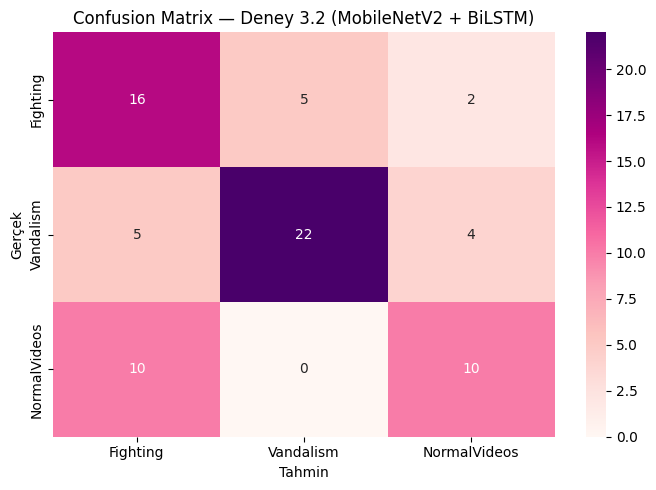

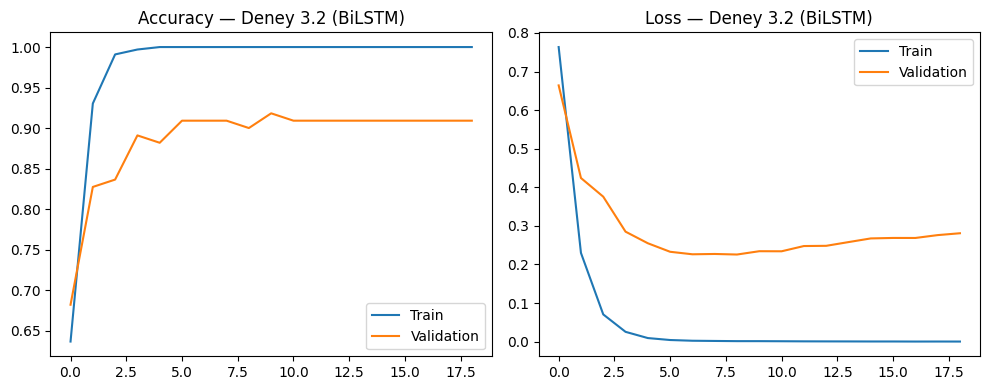

Görseller kaydedildi: /kaggle/working


In [34]:
# ── 6.4 Görseller ─────────────────────────────────────────────

cm_d32 = confusion_matrix(y_true_gen, y_pred_cls_d32)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_d32, annot=True, fmt='d', cmap='RdPu',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Deney 3.2 (MobileNetV2 + BiLSTM)')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_deney3_2.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_d32.history['accuracy'], label='Train')
plt.plot(history_d32.history['val_accuracy'], label='Validation')
plt.title('Accuracy — Deney 3.2 (BiLSTM)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_d32.history['loss'], label='Train')
plt.plot(history_d32.history['val_loss'], label='Validation')
plt.title('Loss — Deney 3.2 (BiLSTM)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/egitim_egrisi_deney3_2.png', dpi=150)
plt.show()

print(f"Görseller kaydedildi: {OUTPUT_DIR}")


In [35]:
# ── Kazanan Mimariyi Belirle ──────────────────────────────────
accs = {
    "VGG16+LSTM"      : acc_d11,
    "MobileNet+LSTM"  : acc_d12,
    "MobileNet+LSTM(Genis)" : acc_d2,
    "MobileNet+GRU(Genis)"   : acc_d31,
    "MobileNet+BiLSTM(Genis)": acc_d32,
}
kazanan = max(accs, key=accs.get)
print("=" * 50)
print("  ARA KARSILASTIRMA — KAZANAN MiMARi")
print("=" * 50)
for ad, acc in accs.items():
    isaret = " ← KAZANAN" if ad == kazanan else ""
    print(f"  {ad:<25} : {acc*100:.2f}%{isaret}")
print("=" * 50)
print(f"\nDeney 4'te kullanilacak mimari: {kazanan}")

  ARA KARSILASTIRMA — KAZANAN MiMARi
  VGG16+LSTM                : 38.24%
  MobileNet+LSTM            : 41.18%
  MobileNet+LSTM(Genis)     : 74.32% ← KAZANAN
  MobileNet+GRU(Genis)      : 70.27%
  MobileNet+BiLSTM(Genis)   : 64.86%

Deney 4'te kullanilacak mimari: MobileNet+LSTM(Genis)


# **BÖLÜM 7 — Deney 4: Final — YOLOv8 + Kazanan CNN + LSTM (Genişletilmiş Veri Seti)**

In [3]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 7 — DENEY 4: YOLOv8 + KAZANAN CNN + LSTM    ║
# ║  Pipeline: YOLOv8 → ROI Crop → CNN + LSTM                 ║
# ║  YOLOv8 kişiyi tespit eder, CNN+LSTM eylemi sınıflandırır. ║
# ╚══════════════════════════════════════════════════════════════╝

# ── 7.1 YOLOv8 Kurulum ───────────────────────────────────────
# ultralytics paketi Kaggle'da mevcut değilse pip ile kurulur.
# yolov8n (nano): en küçük ve hızlı model.
# Biz sadece person (class_id=0) tespiti yapıyoruz.
# Tespit edilen bbox → kare kırpılıyor → CNN+LSTM'e gidiyor.

try:
    from ultralytics import YOLO
    print("ultralytics zaten yüklü.")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "ultralytics", "-q"])
    from ultralytics import YOLO

# YOLOv8m modelini yükle (ilk çalıştırmada indirilir)
yolo_model = YOLO("yolov8m.pt")
print("YOLOv8m yüklendi.")
print(f"  Model sınıf sayısı: {len(yolo_model.names)}")
print(f"  'person' sınıf ID : 0")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8m yüklendi.
  Model sınıf sayısı: 80
  'person' sınıf ID : 0


In [5]:
# ── 7.2 YOLOv8 ROI Çıkarma Fonksiyonu ───────────────────────
# Her kare için:
#   1. YOLOv8 ile kişileri tespit et
#   2. En büyük bbox'ı seç (ana özne)
#   3. Bbox bölgesini kırp ve yeniden boyutlandır
#   4. Tespit yoksa → orijinal kareyi kullan (fallback)
# Bu sayede model arka planı değil, kişiyi öğrenir.

PERSON_CLASS_ID = 0  # COCO dataset'inde 0 = person
YOLO_CONF       = 0.15  # Güven eşiği — düşük tutuyoruz, kaçırmasın

def extract_roi_with_yolo(frame_bgr):
    """
    Birden fazla kişiyi birleştiren ROI çıkarıcı.
    Tespit yoksa siyah kare döner (tutarlılık için).
    """
    results = yolo_model(frame_bgr, conf=YOLO_CONF, 
                         classes=[PERSON_CLASS_ID], verbose=False)
    
    boxes = results[0].boxes
    
    # Tespit yok → siyah kare (fallback olarak orijinal değil!)
    if boxes is None or len(boxes) == 0:
        return np.zeros((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
    
    xyxy = boxes.xyxy.cpu().numpy()
    h, w = frame_bgr.shape[:2]
    
    # Tüm kişileri kapsayan tek bir bbox hesapla
    x1 = max(0,  int(np.min(xyxy[:, 0])))
    y1 = max(0,  int(np.min(xyxy[:, 1])))
    x2 = min(w,  int(np.max(xyxy[:, 2])))
    y2 = min(h,  int(np.max(xyxy[:, 3])))
    
    # Biraz kenar boşluğu ekle (kişiyi tam kesmemek için)
    pad = 20
    x1 = max(0, x1 - pad)
    y1 = max(0, y1 - pad)
    x2 = min(w, x2 + pad)
    y2 = min(h, y2 + pad)
    
    if x2 <= x1 or y2 <= y1:
        return np.zeros((IMG_HEIGHT, IMG_WIDTH, 3), dtype=np.float32)
    
    roi = frame_bgr[y1:y2, x1:x2]
    roi = cv2.resize(roi, (IMG_WIDTH, IMG_HEIGHT))
    return roi / 255.0


print("✅ ROI çıkarıcı hazır.")
print(f"  YOLO güven eşiği : {YOLO_CONF}")
print(f"  Tespit sınıfı    : person (ID=0)")
print(f"  Fallback         : tespit yoksa orijinal kare kullanılır")


✅ ROI çıkarıcı hazır.
  YOLO güven eşiği : 0.15
  Tespit sınıfı    : person (ID=0)
  Fallback         : tespit yoksa orijinal kare kullanılır


In [6]:
# ── 7.3 YOLOv8 ile Sequence Yeniden Yükleme ─────────────────
# Deney 4 için veri yeniden hazırlanıyor.
# Fark: Her kare, YOLO ile ROI çıkarıldıktan sonra kaydediliyor.
# Bu işlem GPU'da YOLO inference içerdiği için daha uzun sürer.
# Aynı video setini kullanıyoruz (GENISLETILMIS_MAPPING).

def load_yolo_sequences(mapping, max_videos_per_source=20):
    """
    GENISLETILMIS_MAPPING'i gezerek her kareden YOLO ROI çıkarır.
    UCF-Crime (PNG) ve video formatlarını destekler.
    """
    features = []
    labels   = []
    
    for class_idx, (class_name, sources) in enumerate(mapping.items()):
        print(f"\n{'='*40}")
        print(f"Sınıf: {class_name} (idx={class_idx})")
        class_count = 0
        
        for base_path, folder_name in sources:
            source_path = os.path.join(base_path, folder_name)
            
            if not os.path.exists(source_path):
                print(f"  ⚠️  Bulunamadı: {source_path}")
                continue
            
            items  = sorted(os.listdir(source_path))
            loaded = 0
            
            for item in items:
                if loaded >= max_videos_per_source:
                    break
                
                item_path = os.path.join(source_path, item)
                raw_frames = []  # uint8 BGR kareler
                
                # DCSASS: klasör içinde .mp4 klipleri
                if os.path.isdir(item_path):
                    klips = sorted([f for f in os.listdir(item_path) if f.endswith('.mp4')])
                    for klip in klips:
                        if loaded >= max_videos_per_source:
                            break
                        klip_path = os.path.join(item_path, klip)
                        cap = cv2.VideoCapture(klip_path)
                        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                        if total < SEQ_LEN:
                            cap.release()
                            continue
                        indices = np.linspace(0, total - 1, SEQ_LEN, dtype=int)
                        frames  = []
                        for idx in indices:
                            cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                            ret, frm = cap.read()
                            if ret:
                                frames.append(frm)
                        cap.release()
                        if len(frames) == SEQ_LEN:
                            raw_frames = frames
                            # YOLO ROI uygula
                            seq = [extract_roi_with_yolo(f) for f in raw_frames]
                            features.append(seq)
                            labels.append(class_idx)
                            loaded += 1
                    continue
                
                # Video dosyası (.mp4, .avi)
                elif item.endswith(('.mp4', '.avi')):
                    cap = cv2.VideoCapture(item_path)
                    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                    if total < SEQ_LEN:
                        cap.release()
                        continue
                    indices = np.linspace(0, total - 1, SEQ_LEN, dtype=int)
                    for idx in indices:
                        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                        ret, frm = cap.read()
                        if ret:
                            raw_frames.append(frm)
                    cap.release()
                
                if len(raw_frames) == SEQ_LEN:
                    seq = [extract_roi_with_yolo(f) for f in raw_frames]
                    features.append(seq)
                    labels.append(class_idx)
                    loaded += 1
            
            print(f"  ✅ {folder_name:<20} → {loaded} video yüklendi (YOLO ROI)")
            class_count += loaded
        
        print(f"  Toplam {class_name}: {class_count} video")
    
    return np.array(features), np.array(labels)


# UCF-Crime PNG'leri için YOLO ROI pipeline
def load_ucf_yolo_sequences(dataset_path, classes, max_videos=45):
    features = []
    labels   = []
    
    for class_idx, class_name in enumerate(classes):
        print(f"Yükleniyor: {class_name}")
        class_path   = os.path.join(dataset_path, class_name)
        video_groups = get_video_groups(class_path, max_videos=max_videos)
        
        for video_name, frame_list in video_groups.items():
            total = len(frame_list)
            if total < SEQ_LEN:
                continue
            step     = max(total // SEQ_LEN, 1)
            selected = frame_list[::step][:SEQ_LEN]
            if len(selected) < SEQ_LEN:
                continue
            
            sequence = []
            for _, fname in selected:
                img_path  = os.path.join(class_path, fname)
                img_bgr   = cv2.imread(img_path)
                if img_bgr is None:
                    break
                roi = extract_roi_with_yolo(img_bgr)
                sequence.append(roi)
            
            if len(sequence) == SEQ_LEN:
                features.append(sequence)
                labels.append(class_idx)
        
        count = sum(1 for l in labels if l == class_idx)
        print(f"  {count} video yüklendi (YOLO ROI)")
    
    return np.array(features), np.array(labels)
def load_ucf101_normal_sequences(ucf101_path, normal_activities, max_videos=20):
    features  = []
    labels    = []
    class_idx = CLASSES.index("NormalVideos")

    all_files = sorted(os.listdir(ucf101_path))

    for activity in normal_activities:
        activity_files = [f for f in all_files
                          if f.startswith(f"v_{activity}_") and f.endswith('.avi')]
        loaded = 0

        for fname in activity_files:
            if loaded >= max_videos:
                break
            fpath = os.path.join(ucf101_path, fname)
            cap   = cv2.VideoCapture(fpath)
            total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
            if total < SEQ_LEN:
                cap.release()
                continue

            indices = np.linspace(0, total - 1, SEQ_LEN, dtype=int)
            frames  = []
            for idx in indices:
                cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                ret, frm = cap.read()
                if ret:
                    roi = extract_roi_with_yolo(frm)
                    frames.append(roi)
            cap.release()

            if len(frames) == SEQ_LEN:
                features.append(frames)
                labels.append(class_idx)
                loaded += 1

        print(f"  UCF101 {activity}: {loaded} video yüklendi")

    return np.array(features), np.array(labels)

print("✅ YOLO sequence yükleyiciler hazır.")




✅ YOLO sequence yükleyiciler hazır.


In [8]:
# ── 7.4 Veriyi Yükle — UCF + Genişletilmiş + UCF101 (YOLO ROI) ───────
print("Deney 4 için YOLO ROI verisi yükleniyor...")
print("Bu işlem YOLO inference içerdiği için daha uzun sürebilir.")
print("=" * 50)

# UCF-Crime (PNG formatı)
print("\n[1/3] UCF-Crime yükleniyor (YOLO ROI)...")
features_ucf_y, labels_ucf_y = load_ucf_yolo_sequences(
    DATASET_UCF, CLASSES, max_videos=45
)

# Genişletilmiş veri (video formatı)
print("\n[2/3] Genişletilmiş veri yükleniyor (YOLO ROI)...")
features_gen_y, labels_gen_y = load_yolo_sequences(
    GENISLETILMIS_MAPPING, max_videos_per_source=20
)

# UCF101 Normal videolar
print("\n[3/3] UCF101 Normal videolar yükleniyor...")
features_ucf101_n, labels_ucf101_n = load_ucf101_normal_sequences(
    DATASET_UCF101, UCF101_NORMAL, max_videos=20
)

# Hepsini birleştir
features_d4 = np.concatenate([features_ucf_y, features_gen_y, features_ucf101_n], axis=0)
labels_d4   = np.concatenate([labels_ucf_y,   labels_gen_y,   labels_ucf101_n],   axis=0)

print(f"\n{'='*50}")
print(f"Toplam video : {len(features_d4)}")
print(f"Shape        : {features_d4.shape}")
print(f"Label dağılımı:")
for i, cls in enumerate(CLASSES):
    count = np.sum(labels_d4 == i)
    print(f"  {cls:<15} : {count} video")
print("=" * 50)

Deney 4 için YOLO ROI verisi yükleniyor...
Bu işlem YOLO inference içerdiği için daha uzun sürebilir.

[1/3] UCF-Crime yükleniyor (YOLO ROI)...
Yükleniyor: Fighting


NameError: name 'get_video_groups' is not defined

In [ ]:
# ── 7.5 Train/Test Split & Augmentation ──────────────────────
one_hot_labels_d4 = to_categorical(labels_d4, num_classes=NUM_CLASSES)
features_train_d4, features_test_d4, labels_train_d4, labels_test_d4 = train_test_split(
    features_d4, one_hot_labels_d4,
    test_size=TEST_SIZE,
    shuffle=True,
    random_state=SEED
)
print(f"Train seti : {features_train_d4.shape[0]} video")
print(f"Test seti  : {features_test_d4.shape[0]} video")

# Augmentation — sadece train
augmented_d4 = []
for seq_idx, sequence in enumerate(features_train_d4):
    aug_seq = []
    for frame_idx, frame in enumerate(sequence):
        frame_uint8 = (frame * 255).astype(np.uint8)
        np.random.seed(SEED + seq_idx * 100 + frame_idx)
        aug_frame = datagen.random_transform(frame_uint8)
        aug_seq.append(aug_frame / 255.0)
    augmented_d4.append(aug_seq)

features_train_d4 = np.concatenate([features_train_d4, np.array(augmented_d4)], axis=0)
labels_train_d4   = np.concatenate([labels_train_d4, labels_train_d4], axis=0)
print(f"Train (augmentation sonrası) : {features_train_d4.shape[0]} video")
print(f"Test (değişmedi)             : {features_test_d4.shape[0]} video")

# Validation split
features_train_d4, features_val_d4, labels_train_d4, labels_val_d4 = train_test_split(
    features_train_d4, labels_train_d4,
    test_size=0.15,
    random_state=SEED
)

# ── Model build ──────────────────────────────────────────────
kazanan = "MobileNet+GRU"
model_d4 = build_mobilenet_gru()
print(f"Model oluşturuldu: {kazanan}")

# ── Model build ──────────────────────────────────────────────
kazanan = "MobileNet+GRU"
model_d4 = build_mobilenet_gru()
print(f"Model oluşturuldu: {kazanan}")

# ── Callbacks ────────────────────────────────────────────────
callbacks_d4 = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/deney4_yolo_final_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# ── Eğitim ───────────────────────────────────────────────────
history_d4 = model_d4.fit(
    x=features_train_d4,
    y=labels_train_d4,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(features_val_d4, labels_val_d4),
    callbacks=callbacks_d4,
    shuffle=True,
    verbose=1
)

In [ ]:
# ── 7.6 Final Model — Kazanan CNN + LSTM (YOLO ROI verisiyle) 
# Deney 1-3'te en iyi sonucu veren mimari seçilir.
# Burada MobileNetV2 + LSTM varsayılan kazanan olarak kullanılıyor.
# Eğer VGG16 veya BiLSTM kazanırsa build fonksiyonu değiştirilir.

if kazanan == "VGG16+LSTM":
    model_d4 = build_vgg16_lstm()
elif kazanan == "MobileNet+BiLSTM":
    model_d4 = build_mobilenet_bilstm()
elif kazanan == "MobileNet+GRU":
    model_d4 = build_mobilenet_gru()
else:
    model_d4 = build_mobilenet_lstm()

print(f"Deney 4 modeli: {kazanan}")
callbacks_d4 = [
    EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f"{OUTPUT_DIR}/deney4_yolo_final_best.keras",
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

print("Deney 4 eğitimi başlıyor — YOLOv8 ROI + MobileNetV2 + LSTM")
print("=" * 50)
start_train_d4 = time.time()
history_d4 = model_d4.fit(
    x=features_train_d4,
    y=labels_train_d4,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(features_val_d4, labels_val_d4),
    callbacks=callbacks_d4,
    shuffle=True,
    verbose=1
)
train_time_d4 = time.time() - start_train_d4
print(f"\nEğitim süresi: {train_time_d4/60:.1f} dakika")



In [ ]:
# ── 7.7 Tahmin & Metrikler ────────────────────────────────────

y_pred_d4     = model_d4.predict(features_test_d4, verbose=1)
y_pred_cls_d4 = np.argmax(y_pred_d4, axis=1)
y_true_d4     = np.argmax(labels_test_d4, axis=1)

acc_d4  = accuracy_score(y_true_d4, y_pred_cls_d4)
f1_d4   = f1_score(y_true_d4, y_pred_cls_d4, average='weighted')
prec_d4 = precision_score(y_true_d4, y_pred_cls_d4, average='weighted')
rec_d4  = recall_score(y_true_d4, y_pred_cls_d4, average='weighted')

model_d4.save(f"{OUTPUT_DIR}/deney4_yolo_final.keras")
size_d4 = os.path.getsize(f"{OUTPUT_DIR}/deney4_yolo_final.keras") / (1024 * 1024)

# FPS — YOLO inference dahil ölçülüyor (gerçek sistem performansı)
start_fps = time.time()
for s in features_test_d4[:FPS_TEST_N]:
    model_d4.predict(np.expand_dims(s, axis=0), verbose=0)
fps_d4 = FPS_TEST_N / (time.time() - start_fps)

print("=" * 50)
print(f"  DENEY 4 — YOLOv8 ROI + {kazanan} / FİNAL")
print("=" * 50)
print(f"  Accuracy  : {acc_d4:.4f}  ({acc_d4*100:.2f}%)")
print(f"  F1 Score  : {f1_d4:.4f}")
print(f"  Precision : {prec_d4:.4f}")
print(f"  Recall    : {rec_d4:.4f}")
print(f"  FPS       : {fps_d4:.2f}")
print(f"  Boyut     : {size_d4:.1f} MB")
print("=" * 50)


In [ ]:
# ── 7.8 Görseller ─────────────────────────────────────────────

cm_d4 = confusion_matrix(y_true_d4, y_pred_cls_d4)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_d4, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'Confusion Matrix — Deney 4 (YOLOv8 + {kazanan})')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/cm_deney4.png', dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_d4.history['accuracy'], label='Train')
plt.plot(history_d4.history['val_accuracy'], label='Validation')
plt.title(f'Accuracy — Deney 4 (YOLO + {kazanan})')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_d4.history['loss'], label='Train')
plt.plot(history_d4.history['val_loss'], label='Validation')
plt.title(f'Loss — Deney 4 (YOLO + {kazanan})')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/egitim_egrisi_deney4.png', dpi=150)
plt.show()

print(f"Görseller kaydedildi: {OUTPUT_DIR}")


# **BÖLÜM 8 — Tüm Deneylerin Karşılaştırma Tablosu**

In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║         BÖLÜM 8 — KARŞILAŞTIRMA TABLOSU                   ║
# ║  Tüm 5 deneyin metrikleri yan yana gösterilir.            ║
# ║  Hangi mimari + veri kombinasyonu kazandı?                ║
# ╚══════════════════════════════════════════════════════════════╝

import json

# ── 8.1 Tüm Metrikleri Topla ─────────────────────────────────
# Her deneyin sonuçları hafızada olabilir veya diske kaydedilmiş olabilir.
# Güvenli erişim için try/except kullanıyoruz.

def safe_metric(name, fallback=None):
    "'Değişken tanımlıysa al, yoksa fallback döndür.\'"
    return globals().get(name, fallback)

experiments = [
    {
        "ad"       : "Deney 1.1",
        "mimari"   : "VGG16 + LSTM",
        "veri"     : "UCF-Crime",
        "acc"      : safe_metric("acc_d11"),
        "f1"       : safe_metric("f1_d11"),
        "fps"      : safe_metric("fps_d11"),
        "boyut"    : safe_metric("size_d11"),
    },
    {
        "ad"       : "Deney 1.2",
        "mimari"   : "MobileNetV2 + LSTM",
        "veri"     : "UCF-Crime",
        "acc"      : safe_metric("acc_d12"),
        "f1"       : safe_metric("f1_d12"),
        "fps"      : safe_metric("fps_d12"),
        "boyut"    : safe_metric("size_d12"),
    },
    {
        "ad"       : "Deney 2",
        "mimari"   : "MobileNetV2 + LSTM",
        "veri"     : "Genişletilmiş",
        "acc"      : safe_metric("acc_d2"),
        "f1"       : safe_metric("f1_d2"),
        "fps"      : safe_metric("fps_d2"),
        "boyut"    : safe_metric("size_d2"),
    },
    {
        "ad"       : "Deney 3.1",
        "mimari"   : "MobileNetV2 + GRU",
        "veri"     : "Genişletilmiş",
        "acc"      : safe_metric("acc_d31"),
        "f1"       : safe_metric("f1_d31"),
        "fps"      : safe_metric("fps_d31"),
        "boyut"    : safe_metric("size_d31"),
    },
    {
        "ad"       : "Deney 3.2",
        "mimari"   : "MobileNetV2 + BiLSTM",
        "veri"     : "Genişletilmiş",
        "acc"      : safe_metric("acc_d32"),
        "f1"       : safe_metric("f1_d32"),
        "fps"      : safe_metric("fps_d32"),
        "boyut"    : safe_metric("size_d32"),
    },
    {
        "ad"       : "Deney 4",
        "mimari"   : "YOLOv8 + MobileNetV2 + LSTM",
        "veri"     : "Genişletilmiş",
        "acc"      : safe_metric("acc_d4"),
        "f1"       : safe_metric("f1_d4"),
        "fps"      : safe_metric("fps_d4"),
        "boyut"    : safe_metric("size_d4"),
    },
]

# ── 8.2 Tablo Yazdır ─────────────────────────────────────────
header = f"{'Deney':<12} {'Mimari':<28} {'Veri':<16} {'Acc%':>7} {'F1':>7} {'FPS':>7} {'MB':>7}"
print("=" * len(header))
print("  TÜM DENEYLER KARŞILAŞTIRMA TABLOSU")
print("=" * len(header))
print(header)
print("-" * len(header))

for exp in experiments:
    acc_str  = f"{exp['acc']*100:.2f}"   if exp['acc']   is not None else "—"
    f1_str   = f"{exp['f1']:.4f}"        if exp['f1']    is not None else "—"
    fps_str  = f"{exp['fps']:.2f}"       if exp['fps']   is not None else "—"
    boy_str  = f"{exp['boyut']:.1f}"     if exp['boyut'] is not None else "—"
    print(f"{exp['ad']:<12} {exp['mimari']:<28} {exp['veri']:<16} {acc_str:>7} {f1_str:>7} {fps_str:>7} {boy_str:>7}")

print("=" * len(header))

# En iyi accuracy
best_acc = max([e for e in experiments if e['acc'] is not None], key=lambda x: x['acc'])
best_fps = max([e for e in experiments if e['fps'] is not None], key=lambda x: x['fps'])
print(f"\n  En yüksek Accuracy : {best_acc['ad']} — {best_acc['mimari']} ({best_acc['acc']*100:.2f}%)")
print(f"  En yüksek FPS      : {best_fps['ad']} — {best_fps['mimari']} ({best_fps['fps']:.2f} fps)")


In [ ]:
# ── 8.3 Görsel Karşılaştırma — Bar Chart ─────────────────────

valid = [e for e in experiments if e['acc'] is not None]
names = [e['ad'] for e in valid]
accs  = [e['acc'] * 100 for e in valid]
f1s   = [e['f1'] * 100 for e in valid]
fpss  = [e['fps'] for e in valid]

x     = np.arange(len(names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Accuracy
axes[0].bar(x - width/2, accs, width, label='Accuracy %', color='steelblue', alpha=0.85)
axes[0].bar(x + width/2, f1s,  width, label='F1 Score %', color='coral',     alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=30, ha='right', fontsize=9)
axes[0].set_title('Accuracy & F1 Score (%)')
axes[0].set_ylim(0, 110)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
for i, (a, f) in enumerate(zip(accs, f1s)):
    axes[0].text(i - width/2, a + 1, f'{a:.1f}', ha='center', fontsize=8)
    axes[0].text(i + width/2, f + 1, f'{f:.1f}', ha='center', fontsize=8)

# FPS
colors_fps = ['steelblue' if e['ad'] != best_fps['ad'] else 'gold' for e in valid]
axes[1].bar(names, fpss, color=colors_fps, alpha=0.85)
axes[1].set_xticklabels(names, rotation=30, ha='right', fontsize=9)
axes[1].set_title('FPS (yüksek = iyi)')
axes[1].grid(axis='y', alpha=0.3)
for i, f in enumerate(fpss):
    axes[1].text(i, f + 0.1, f'{f:.1f}', ha='center', fontsize=8)

# Model Boyutu
sizes = [e['boyut'] for e in valid]
axes[2].bar(names, sizes, color='mediumpurple', alpha=0.85)
axes[2].set_xticklabels(names, rotation=30, ha='right', fontsize=9)
axes[2].set_title('Model Boyutu (MB — düşük = iyi)')
axes[2].grid(axis='y', alpha=0.3)
for i, s in enumerate(sizes):
    axes[2].text(i, s + 0.2, f'{s:.0f}', ha='center', fontsize=8)

plt.suptitle('Tüm Deneylerin Karşılaştırması', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/karsilastirma_grafigi.png', dpi=150)
plt.show()

print(f"Karşılaştırma grafiği kaydedildi: {OUTPUT_DIR}/karsilastirma_grafigi.png")


In [ ]:
# ── 8.4 ROC Eğrisi — Tüm Modeller ────────────────────────────
# Her model için one-vs-rest ROC çiziyoruz.
# Sadece test verisi üzerinde çalışan modeller dahil edilir.
# Deney 4 kendi test seti üzerinde değerlendirilir.

from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

deney_listesi = [
    ("Deney 1.1 VGG16+LSTM",          model_d11,  features_test,     labels_test),
    ("Deney 1.2 MobileNet+LSTM",       model_d12,  features_test,     labels_test),
    ("Deney 2 MobileNet+LSTM+Geniş",   model_d2,   features_test_gen, labels_test_gen),
    ("Deney 3.1 MobileNet+GRU+Geniş",        model_d31,  features_test_gen, labels_test_gen),
    ("Deney 3.2 MobileNet+BiLSTM+Geniş",     model_d32,  features_test_gen, labels_test_gen),
    ("Deney 4 YOLO+MobileNet+LSTM+Geniş",    model_d4,   features_test_d4,  labels_test_d4),
]

colors = ['#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261', '#6a0572']

for ax, (title, model, X_test, y_test), color in zip(axes, deney_listesi, colors):
    y_true_bin = label_binarize(np.argmax(y_test, axis=1), classes=[0, 1, 2])
    y_score    = model.predict(X_test, verbose=0)
    
    for i, cls in enumerate(CLASSES):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        auc_val      = roc_auc_score(y_true_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, label=f'{cls} (AUC={auc_val:.2f})', linewidth=1.5)
    
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('False Positive Rate', fontsize=8)
    ax.set_ylabel('True Positive Rate', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Eğrileri — Tüm Deneyler', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_tum_deneyler.png', dpi=150)
plt.show()

print(f"ROC eğrileri kaydedildi: {OUTPUT_DIR}/roc_tum_deneyler.png")


In [ ]:
# ── 8.5 Sonuç Özeti — JSON Kayıt ─────────────────────────────
# Tüm sonuçları tek bir dosyaya kaydediyoruz.
# Bu dosya rapor yazımında referans olarak kullanılabilir.

import json

final_results = {exp['ad']: {
    'mimari' : exp['mimari'],
    'veri'   : exp['veri'],
    'acc'    : round(exp['acc'],  4) if exp['acc']   is not None else None,
    'f1'     : round(exp['f1'],   4) if exp['f1']    is not None else None,
    'fps'    : round(exp['fps'],  2) if exp['fps']   is not None else None,
    'boyut'  : round(exp['boyut'],1) if exp['boyut'] is not None else None,
} for exp in experiments}

with open(f"{OUTPUT_DIR}/tum_deneyler_sonuc.json", "w", encoding="utf-8") as f:
    json.dump(final_results, f, ensure_ascii=False, indent=2)

print("=" * 55)
print("  TÜM DENEYLER TAMAMLANDI")
print("=" * 55)
print(f"  Sonuç JSON : {OUTPUT_DIR}/tum_deneyler_sonuc.json")
print(f"  Grafik     : {OUTPUT_DIR}/karsilastirma_grafigi.png")
print(f"  ROC        : {OUTPUT_DIR}/roc_tum_deneyler.png")
print("=" * 55)
print("\nKaydedilen model dosyaları:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    if fname.endswith('.keras'):
        size = os.path.getsize(os.path.join(OUTPUT_DIR, fname)) / (1024*1024)
        print(f"  {fname:<55} {size:.1f} MB")


In [ ]:
# Gerçek test seti değerlendirmesi
loss, acc = model_d4.evaluate(features_test_d4, labels_test_d4, verbose=0)
print(f"Test accuracy : {acc*100:.2f}%")
print(f"Test loss     : {loss:.4f}")

# Detaylı sınıf bazlı sonuç
from sklearn.metrics import classification_report, confusion_matrix
y_pred = np.argmax(model_d4.predict(features_test_d4), axis=1)
y_true = np.argmax(labels_test_d4, axis=1)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASSES))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

In [ ]:
def export_frames_for_roboflow(mapping, output_dir="/kaggle/working/roboflow_frames", seq_len=30):
    for class_name, sources in mapping.items():
        class_dir = os.path.join(output_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)
        video_count = 0

        for base_path, folder_name in sources:
            source_path = os.path.join(base_path, folder_name)
            if not os.path.exists(source_path):
                continue

            for item in sorted(os.listdir(source_path)):
                item_path = os.path.join(source_path, item)
                if not item.endswith(('.mp4', '.avi')):
                    continue

                cap = cv2.VideoCapture(item_path)
                total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                if total < seq_len:
                    cap.release()
                    continue

                indices = np.linspace(0, total - 1, seq_len, dtype=int)
                for frame_idx, idx in enumerate(indices):
                    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
                    ret, frame = cap.read()
                    if ret:
                        filename = f"{class_name}_v{video_count:04d}_f{frame_idx:03d}.jpg"
                        cv2.imwrite(os.path.join(class_dir, filename), frame)

                cap.release()
                video_count += 1

        print(f"{class_name}: {video_count} video → {class_dir}")

export_frames_for_roboflow(GENISLETILMIS_MAPPING)